### Imports

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib
import sys
sys.path.append('/teamspace/studios/this_studio/Human-Activity-Recognition')
from src.rnn import build_rnn
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

### Load & Preprocess Raw Sensor Data

In [5]:
sensor_names = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',     # Accelerometer measurements
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',  # Gyroscope measurements
    'total_acc_x', 'total_acc_y', 'total_acc_z'     # Raw accelerometer measurements before filtering (total acceleration)
]

def load_data(split_type):
    signals = []

    for sensor_name in sensor_names:
        file_path = os.path.join(f'../../data/UCI HAR Dataset/{split_type}/Inertial Signals/{sensor_name}_{split_type}.txt')
        signal = np.array(pd.read_csv(file_path, delim_whitespace=True, header=None).values)
        signals.append(signal)

    return np.array(signals).transpose(1, 2, 0)

def load_labels(split_type):
    file_path = os.path.join(f'../../data/UCI HAR Dataset/{split_type}/y_{split_type}.txt')
    # Convert 1 - 6 to 0 - 5
    return pd.read_csv(file_path, delim_whitespace=True, header=None).values.flatten() - 1


def normalize_data(X_train_raw, X_test_raw):
    n_samples_train, n_timesteps, n_features = X_train_raw.shape
    n_samples_test = X_test_raw.shape[0]

    # Reshape to (samples * timesteps, features) so scaler sees each feature
    X_train_flat = X_train_raw.reshape(-1, n_features)
    X_test_flat  = X_test_raw.reshape(-1, n_features)

    # Fit on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)

    # Reshape back to (samples, timesteps, features)
    X_train_norm = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
    X_test_norm  = X_test_scaled.reshape(n_samples_test,  n_timesteps, n_features)

    return X_train_norm, X_test_norm, scaler

X_train_raw = load_data('train')
X_test_raw = load_data('test')
y_train = load_labels('train')
y_test = load_labels('test')
X_train_norm, X_test_norm, scaler = normalize_data(X_train_raw, X_test_raw)

### Build & Train The RNN Model

In [6]:
model = build_rnn()
model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

history = model.fit(
    X_train_norm, y_train_categorical,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint('../../models/rnn.h5', monitor='val_loss', save_best_only=True)
    ]
)

test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_categorical, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
# model.save('../../models/rnn.h5')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,830 (77.46 KB)

 Trainable params: 19,830 (77.46 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6732 - loss: 0.7888 - val_accuracy: 0.7056 - val_loss: 0.7621
Epoch 3/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7088 - loss: 0.6922

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7240 - loss: 0.6753 - val_accuracy: 0.7933 - val_loss: 0.6877
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7567 - loss: 0.7366 - val_accuracy: 0.5343 - val_loss: 1.3674
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5831 - loss: 1.1125 - val_accuracy: 0.7226 - val_loss: 0.7217
Epoch 6/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7041 - loss: 0.7496

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7237 - loss: 0.7025 - val_accuracy: 0.7770 - val_loss: 0.6569
Epoch 7/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7620 - loss: 0.6176

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7779 - loss: 0.5921 - val_accuracy: 0.8144 - val_loss: 0.5810
Epoch 8/30
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8506 - loss: 0.4857

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8507 - loss: 0.4771 - val_accuracy: 0.8579 - val_loss: 0.4845
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7099 - loss: 0.8504 - val_accuracy: 0.6383 - val_loss: 0.9235
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6482 - loss: 0.8945 - val_accuracy: 0.7675 - val_loss: 0.6593
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7878 - loss: 0.6090 - val_accuracy: 0.7933 - val_loss: 0.6399
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8022 - loss: 0.5637 - val_accuracy: 0.8124 - val_loss: 0.5754
Epoch 13/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8181 - loss: 0.5411 - val_accuracy: 0.8042 - val_loss: 0.6337
Epoch 14/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8563 - loss: 0.4763 - val_accuracy: 0.7967 - val_loss: 0.6828
Epoch 15/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8329 - loss: 0.5173 - val_accuracy: 0.8722 - val_lo

### Plots

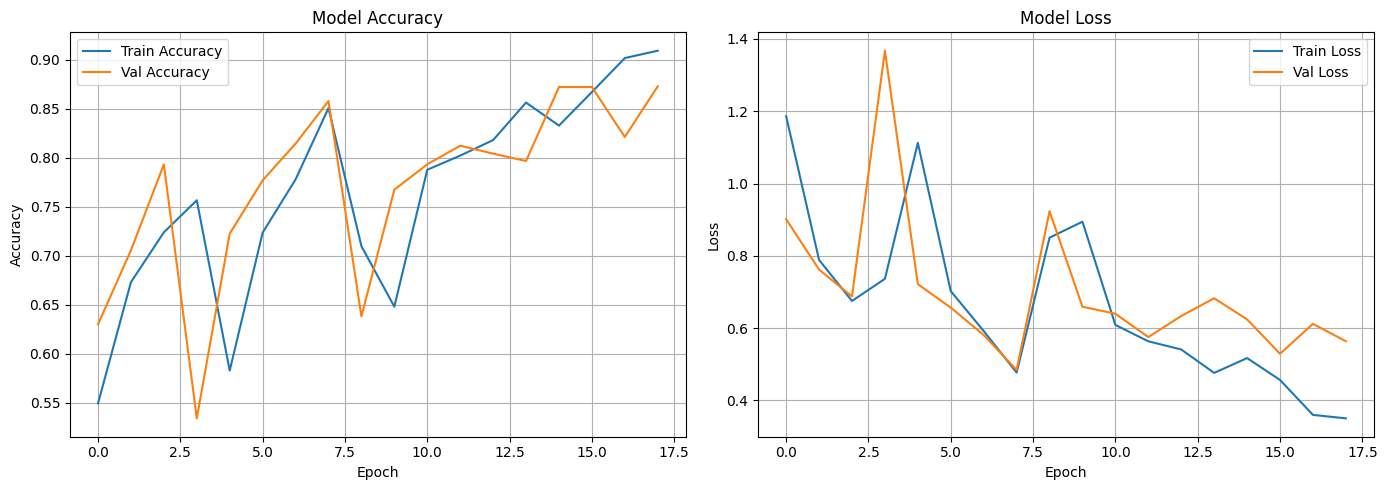

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()